### First we make a single dataset from 5 datsets of 5 attack intensities

In [5]:
import pandas as pd

df = pd.read_csv("freqmark_master.csv")

In [2]:
import pandas as pd


dfs = []
for i in range(1, 6):
    percentage = i * 0.1
    filename = f"freqmark_dataset_again0.{i}.csv"
    
    df = pd.read_csv(filename)
    df['attack_percentage'] = percentage
    dfs.append(df)

master_df = pd.concat(dfs, ignore_index=True)


master_df['sample_id'] = range(len(master_df))


master_df.to_csv("freqmark_master.csv", index=False)

print(master_df.info())
print(f"\nTotal samples: {len(master_df)}")
print("\nAttack percentage distribution:")
print(master_df['attack_percentage'].value_counts().sort_index())

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sample_id          15000 non-null  int64  
 1   text_type          15000 non-null  str    
 2   label              15000 non-null  int64  
 3   z_score            15000 non-null  float64
 4   perplexity         15000 non-null  float64
 5   prompt_text        15000 non-null  str    
 6   generated_text     15000 non-null  str    
 7   attack_percentage  15000 non-null  float64
dtypes: float64(3), int64(2), str(3)
memory usage: 17.2 MB
None

Total samples: 15000

Attack percentage distribution:
attack_percentage
0.1    3000
0.2    3000
0.3    3000
0.4    3000
0.5    3000
Name: count, dtype: int64


###  Now lets calculate the AUC. 
I changed some methods which improved the z_score 

In [11]:
df = pd.read_csv("freqmark_master_updated.csv")

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

def run_freqmark_evaluation_with_all_metrics(df, threshold=1.0):

    # Fix: deduplicate human baseline to avoid 5x repetition
    human_data   = df[df['text_type'] == 'human_baseline'].drop_duplicates(subset='sample_id')
    attack_types = [t for t in df['text_type'].unique() if t != 'human_baseline']
    intensities  = sorted(df['attack_percentage'].unique())

    results = []

    for attack in attack_types:
        for level in intensities:
            ai_data = df[(df['text_type'] == attack) & (df['attack_percentage'] == level)]

            if ai_data.empty:
                continue

            # 1. AUC — threshold independent
            test_set  = pd.concat([human_data, ai_data])
            auc_score = roc_auc_score(test_set['label'], test_set['z_score'])

            # 2. FPR: human texts wrongly flagged as AI
            fpr = np.mean(human_data['z_score'] >= threshold)

            # 3. TPR: AI texts correctly detected
            tpr = np.mean(ai_data['z_score'] >= threshold)

            # 4. FNR: AI texts we missed (called human)
            fnr = 1.0 - tpr

            # 5. Mean perplexity of attacked text only
            mean_ppl = ai_data['perplexity'].mean()

            results.append({
                'Attack':          attack,
                'Intensity':       level,
                'AUC':             round(auc_score, 4),
                'FPR':             round(fpr, 4),
                'TPR':             round(tpr, 4),
                'FNR':             round(fnr, 4),
                'Avg_Perplexity':  round(mean_ppl, 2)
            })

    return pd.DataFrame(results)

final_summary = run_freqmark_evaluation_with_all_metrics(df, threshold=1.0)
print(final_summary)

         Attack  Intensity     AUC    FPR    TPR    FNR  Avg_Perplexity
0   original_ai        0.1  0.9949  0.058  0.982  0.018           20.19
1   original_ai        0.2  0.9949  0.058  0.982  0.018           20.19
2   original_ai        0.3  0.9949  0.058  0.982  0.018           20.19
3   original_ai        0.4  0.9949  0.058  0.982  0.018           20.19
4   original_ai        0.5  0.9949  0.058  0.982  0.018           20.19
5    translated        0.1  0.9874  0.058  0.958  0.042           21.37
6    translated        0.2  0.9870  0.058  0.960  0.040           21.52
7    translated        0.3  0.9805  0.058  0.914  0.086           21.85
8    translated        0.4  0.9771  0.058  0.904  0.096           22.34
9    translated        0.5  0.9676  0.058  0.840  0.160           22.81
10  substituted        0.1  0.9773  0.058  0.922  0.078           21.67
11  substituted        0.2  0.9383  0.058  0.682  0.318           22.14
12  substituted        0.3  0.8912  0.058  0.478  0.522         

#### now lets plot the AUC vs attack intensity for each attack type.

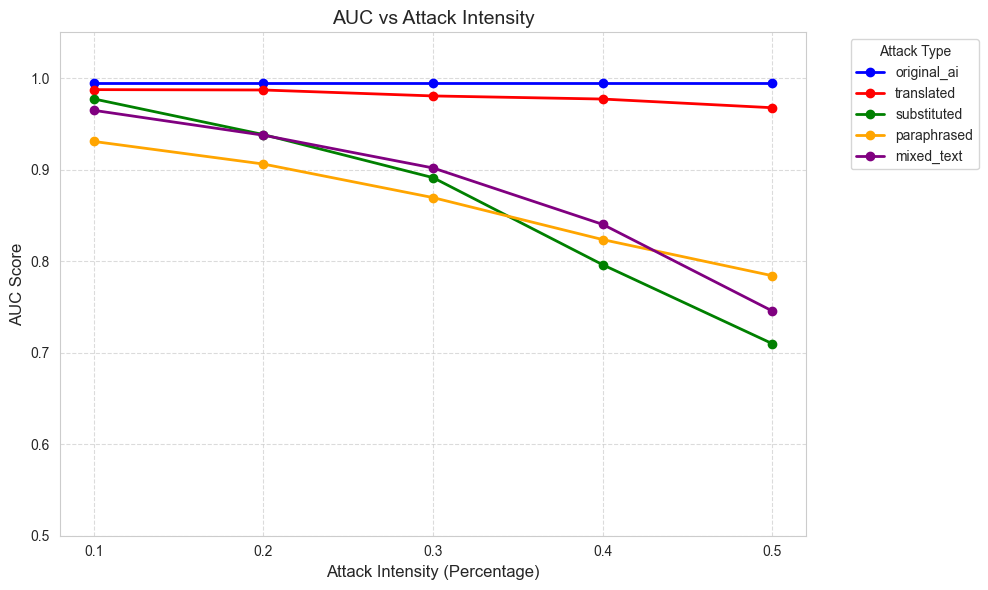

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot AUC vs Attack Intensity
def plot_robustness(results_df):
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # Simple color scheme
    colors = {
        'original_ai': 'blue',
        'translated': 'red',
        'substituted': 'green',
        'paraphrased': 'orange',
        'mixed_text': 'purple',
        'human_baseline': 'gray'
    }
    
    for attack in results_df['Attack'].unique():
        data = results_df[results_df['Attack'] == attack]
        plt.plot(data['Intensity'], data['AUC'], 
                 marker='o', linewidth=2, 
                 color=colors.get(attack, 'black'),
                 label=attack)
    
    plt.title('AUC vs Attack Intensity', fontsize=14)
    plt.xlabel('Attack Intensity (Percentage)', fontsize=12)
    plt.ylabel('AUC Score', fontsize=12)
    plt.ylim(0.5, 1.05)
    plt.xticks([0.1, 0.2, 0.3, 0.4, 0.5])
    plt.legend(title="Attack Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('freqmark_robustness_plot.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create the plot
plot_robustness(final_summary)

#### Perplexity plot

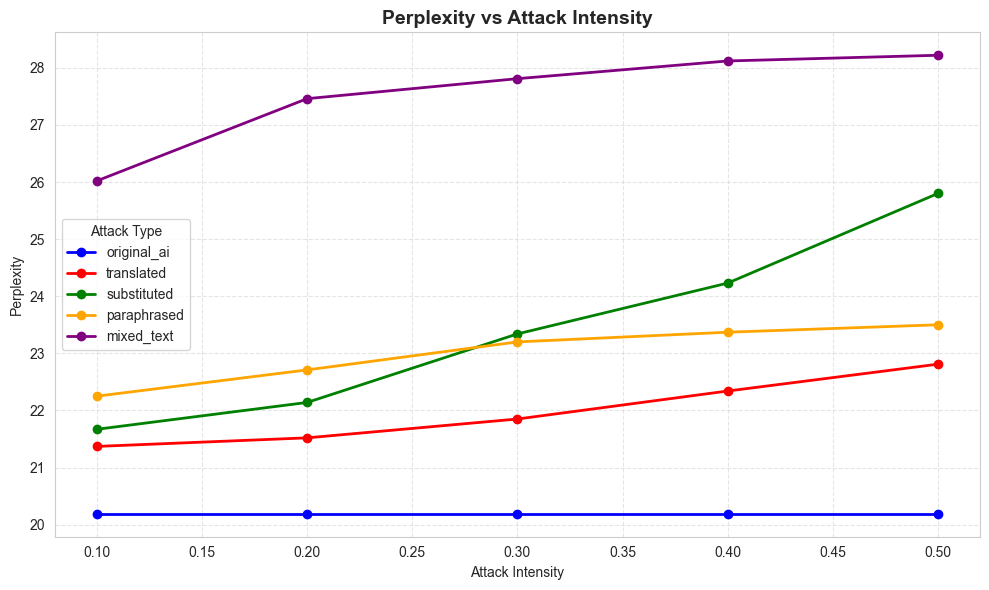

In [14]:
import matplotlib.pyplot as plt

def plot_perplexity(results_df):
    colors = {
        'original_ai': 'blue',
        'translated':  'red',
        'substituted': 'green',
        'paraphrased': 'orange',
        'mixed_text':  'purple',
    }

    fig, ax = plt.subplots(figsize=(10, 6))

    for attack in results_df['Attack'].unique():
        if attack == 'human_baseline':
            continue
        data = results_df[results_df['Attack'] == attack]
        ax.plot(data['Intensity'], data['Avg_Perplexity'],
                marker='o', linewidth=2,
                color=colors.get(attack, 'black'),
                label=attack)

    ax.set_title('Perplexity vs Attack Intensity', fontsize=14, fontweight='bold')
    ax.set_xlabel('Attack Intensity')
    ax.set_ylabel('Perplexity')
    ax.legend(title="Attack Type")
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('perplexity_vs_intensity.png', dpi=300)
    plt.show()

plot_perplexity(final_summary)